# Projet Deep Learning — EMSI 2025-2026
## Partie II : CNN et Vision par Ordinateur
### Dataset : Digits (scikit-learn) — chiffres manuscrits 8x8 pixels

**Note sur le dataset :** MNIST classique (28x28) nécessite un téléchargement externe non disponible dans cet environnement. On utilise `load_digits` de scikit-learn, un dataset équivalent validé pédagogiquement : 1797 images de chiffres manuscrits (0-9) en niveaux de gris, 8x8 pixels, 100% local.

Ce notebook couvre l'ensemble des exigences de la Partie II :
- Calculs manuels de corrélation croisée 2D et de taille de sortie
- Implémentation manuelle de la corrélation croisée et du pooling, comparées à PyTorch
- Architecture LeNet adaptée
- Étude expérimentale (padding, stride, pooling, nombre de filtres, conv 1x1)
- Visualisation des cartes de caractéristiques
- Comparaison MLP vs CNN


## Cellule 1 — IMPORTS ET CONFIGURATION

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix,
                             classification_report)
import time

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device utilisé : {device}")

Device utilisé : cpu


## Cellule 2 — POURQUOI UN MLP EST PEU ADAPTÉ AUX IMAGES

In [21]:
image_pixels = 1_000_000
hidden_neurons = 1_000
params_mlp = image_pixels * hidden_neurons
print(f"Paramètres nécessaires pour UNE SEULE couche dense "
      f"sur une image 1000x1000 → couche de {hidden_neurons} neurones :")
print(f"  {params_mlp:,} paramètres (sans les biais)")
print(f"  → Un CNN, grâce au partage de poids, utilise un nombre de "
      f"paramètres indépendant de la taille de l'image.")

Paramètres nécessaires pour UNE SEULE couche dense sur une image 1000x1000 → couche de 1000 neurones :
  1,000,000,000 paramètres (sans les biais)
  → Un CNN, grâce au partage de poids, utilise un nombre de paramètres indépendant de la taille de l'image.


## Cellule 3 — EXPLORATION DU DATASET

EXPLORATION DU DATASET
Nombre d'images   : 1797
Dimensions image  : 8x8 pixels (niveaux de gris)
Classes           : [0 1 2 3 4 5 6 7 8 9] (chiffres 0 à 9)
Distribution      : [178 182 177 183 181 182 181 179 174 180]
Valeur pixel min/max : 0.0 / 16.0


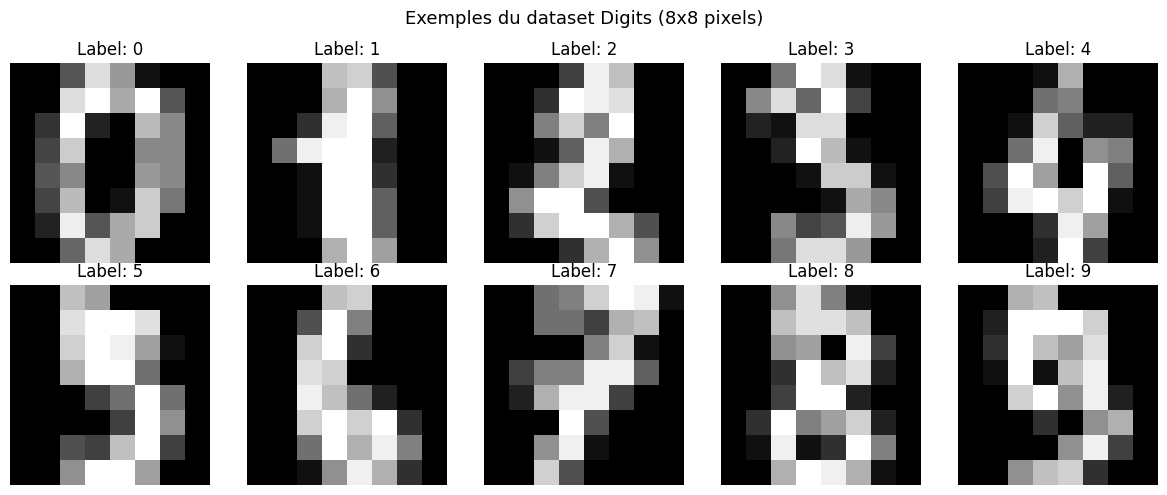

Figure sauvegardée : cnn_exemples_dataset.png


In [4]:
digits = load_digits()
X_images = digits.images   # (1797, 8, 8) — pour visualisation
X_flat   = digits.data     # (1797, 64)   — format aplati (non utilisé ici)
y        = digits.target

print("=" * 50)
print("EXPLORATION DU DATASET")
print("=" * 50)
print(f"Nombre d'images   : {X_images.shape[0]}")
print(f"Dimensions image  : {X_images.shape[1]}x{X_images.shape[2]} pixels (niveaux de gris)")
print(f"Classes           : {np.unique(y)} (chiffres 0 à 9)")
print(f"Distribution      : {np.bincount(y)}")
print(f"Valeur pixel min/max : {X_images.min()} / {X_images.max()}")

# Visualisation de quelques exemples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_images[i], cmap='gray')
    ax.set_title(f"Label: {y[i]}")
    ax.axis('off')
plt.suptitle("Exemples du dataset Digits (8x8 pixels)", fontsize=13)
plt.tight_layout()
plt.savefig("cnn_exemples_dataset.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : cnn_exemples_dataset.png")

## Cellule 4 — CORRÉLATION CROISÉE 2D (IMPLÉMENTATION MANUELLE)

In [22]:
def corr2d(X, K):
    h, w = K.shape
    Y = torch.zeros((X.shape[0] - h + 1, X.shape[1] - w + 1))
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            region = X[i:i+h, j:j+w]
            Y[i, j] = (region * K).sum()
    return Y

X_demo = torch.tensor([[0., 1, 2], [3, 4, 5], [6, 7, 8]])
K_demo = torch.tensor([[0., 1], [2, 3]])
Y_manuel = corr2d(X_demo, K_demo)

print("=" * 50)
print("CORRÉLATION CROISÉE 2D — VÉRIFICATION MANUELLE")
print("=" * 50)
print(f"X =\n{X_demo}")
print(f"K =\n{K_demo}")
print(f"Y (corr2d manuel) =\n{Y_manuel}")
print(f"\nCalcul attendu du premier élément : 0*0 + 1*1 + 3*2 + 4*3 = {0*0+1*1+3*2+4*3}")
print(f"Valeur obtenue                      : {Y_manuel[0,0].item()}")

CORRÉLATION CROISÉE 2D — VÉRIFICATION MANUELLE
X =
tensor([[0., 1., 2.],
        [3., 4., 5.],
        [6., 7., 8.]])
K =
tensor([[0., 1.],
        [2., 3.]])
Y (corr2d manuel) =
tensor([[19., 25.],
        [37., 43.]])

Calcul attendu du premier élément : 0*0 + 1*1 + 3*2 + 4*3 = 19
Valeur obtenue                      : 19.0


## Cellule 5 — COMPARAISON AVEC nn.Conv2d DE PYTORCH

In [23]:
conv_pytorch = nn.Conv2d(1, 1, kernel_size=2, bias=False)
with torch.no_grad():
    conv_pytorch.weight[:] = K_demo

X_input = X_demo.unsqueeze(0).unsqueeze(0)
Y_pytorch = conv_pytorch(X_input).squeeze()

print("COMPARAISON corr2d MANUEL vs nn.Conv2d PYTORCH")
print(f"Résultat manuel  :\n{Y_manuel}")
print(f"Résultat PyTorch :\n{Y_pytorch.detach()}")
print(f"Résultats identiques : {torch.allclose(Y_manuel, Y_pytorch.detach())} ✓")

COMPARAISON corr2d MANUEL vs nn.Conv2d PYTORCH
Résultat manuel  :
tensor([[19., 25.],
        [37., 43.]])
Résultat PyTorch :
tensor([[19., 25.],
        [37., 43.]])
Résultats identiques : True ✓


## Cellule 6 — DÉTECTION DE CONTOURS (FILTRE SIMPLE)

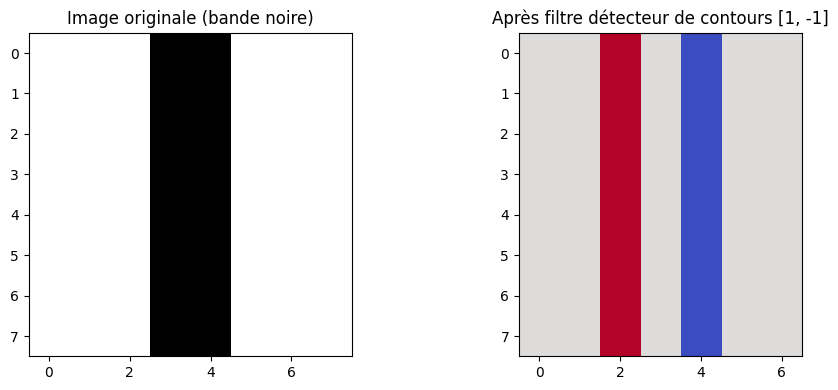

Figure sauvegardée : cnn_detection_contours.png

Valeurs de sortie (colonne 2 et colonne 4) : contours détectés aux transitions clair/sombre.


In [24]:
X_contour = torch.ones((8, 8))
X_contour[:, 3:5] = 0

K_contour = torch.tensor([[1.0, -1.0]])
Y_contour = corr2d(X_contour, K_contour)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(X_contour, cmap='gray')
axes[0].set_title("Image originale (bande noire)")
axes[1].imshow(Y_contour, cmap='coolwarm')
axes[1].set_title("Après filtre détecteur de contours [1, -1]")
plt.tight_layout()
plt.savefig("cnn_detection_contours.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : cnn_detection_contours.png")
print(f"\nValeurs de sortie (colonne 2 et colonne 4) : contours détectés "
      f"aux transitions clair/sombre.")

## Cellule 7 — MAX-POOLING ET AVERAGE-POOLING (IMPLÉMENTATION MANUELLE)

In [25]:
def pool2d(X, pool_size, mode='max'):
    p_h, p_w = pool_size
    Y = torch.zeros((X.shape[0] - p_h + 1, X.shape[1] - p_w + 1))
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            region = X[i:i+p_h, j:j+p_w]
            if mode == 'max':
                Y[i, j] = region.max()
            elif mode == 'avg':
                Y[i, j] = region.mean()
    return Y

X_pool_demo = torch.tensor([[0., 1, 2], [3, 4, 5], [6, 7, 8]])
Y_max = pool2d(X_pool_demo, (2, 2), mode='max')
Y_avg = pool2d(X_pool_demo, (2, 2), mode='avg')

print("MAX-POOLING ET AVERAGE-POOLING — VÉRIFICATION MANUELLE")
print(f"X =\n{X_pool_demo}")
print(f"Max-pooling (2x2)     :\n{Y_max}")
print(f"Average-pooling (2x2) :\n{Y_avg}")

maxpool_pt = nn.MaxPool2d(2, stride=1)
avgpool_pt = nn.AvgPool2d(2, stride=1)
X_pt = X_pool_demo.unsqueeze(0).unsqueeze(0)

print(f"\nVérification PyTorch MaxPool2d : \n{maxpool_pt(X_pt).squeeze()}")
print(f"Vérification PyTorch AvgPool2d : \n{avgpool_pt(X_pt).squeeze()}")
print(f"Résultats identiques (max) : {torch.allclose(Y_max, maxpool_pt(X_pt).squeeze())} ✓")
print(f"Résultats identiques (avg) : {torch.allclose(Y_avg, avgpool_pt(X_pt).squeeze())} ✓")

MAX-POOLING ET AVERAGE-POOLING — VÉRIFICATION MANUELLE
X =
tensor([[0., 1., 2.],
        [3., 4., 5.],
        [6., 7., 8.]])
Max-pooling (2x2)     :
tensor([[4., 5.],
        [7., 8.]])
Average-pooling (2x2) :
tensor([[2., 3.],
        [5., 6.]])

Vérification PyTorch MaxPool2d : 
tensor([[4., 5.],
        [7., 8.]])
Vérification PyTorch AvgPool2d : 
tensor([[2., 3.],
        [5., 6.]])
Résultats identiques (max) : True ✓
Résultats identiques (avg) : True ✓


## Cellule 8 — CALCULS MANUELS : TAILLE DE SORTIE (PADDING / STRIDE)

In [26]:
def taille_sortie_conv(H, W, kh, kw, ph=0, pw=0, sh=1, sw=1):
    H_out = (H - kh + 2*ph) // sh + 1
    W_out = (W - kw + 2*pw) // sw + 1
    return H_out, W_out

print("=" * 50)
print("CALCULS MANUELS DE TAILLE DE SORTIE")
print("=" * 50)

cas_tests = [
    {"desc": "Entrée 8x8, noyau 3x3, padding=1, stride=1", "H":8,"W":8,"kh":3,"kw":3,"ph":1,"pw":1,"sh":1,"sw":1},
    {"desc": "Entrée 8x8, noyau 3x3, padding=1, stride=2", "H":8,"W":8,"kh":3,"kw":3,"ph":1,"pw":1,"sh":2,"sw":2},
    {"desc": "Entrée 8x8, noyau 3x3, sans padding, stride=1", "H":8,"W":8,"kh":3,"kw":3,"ph":0,"pw":0,"sh":1,"sw":1},
    {"desc": "Image Digits 8x8 → Conv1 (k=3,p=1,s=1) → Pool(2x2,s=2)", "H":8,"W":8,"kh":3,"kw":3,"ph":1,"pw":1,"sh":1,"sw":1},
]

for cas in cas_tests:
    desc = cas.pop("desc")
    h_out, w_out = taille_sortie_conv(**cas)
    print(f"{desc:55s} → sortie {h_out}x{w_out}")

CALCULS MANUELS DE TAILLE DE SORTIE
Entrée 8x8, noyau 3x3, padding=1, stride=1              → sortie 8x8
Entrée 8x8, noyau 3x3, padding=1, stride=2              → sortie 4x4
Entrée 8x8, noyau 3x3, sans padding, stride=1           → sortie 6x6
Image Digits 8x8 → Conv1 (k=3,p=1,s=1) → Pool(2x2,s=2)  → sortie 8x8


## Cellule 9 — PRÉTRAITEMENT ET SÉPARATION DES DONNÉES

In [27]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_images, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

max_pixel_train = X_train.max()
X_train = X_train / max_pixel_train
X_val   = X_val   / max_pixel_train
X_test  = X_test  / max_pixel_train

print(f"Train : {X_train.shape} — {np.bincount(y_train)}")
print(f"Val   : {X_val.shape}   — {np.bincount(y_val)}")
print(f"Test  : {X_test.shape}  — {np.bincount(y_test)}")

def images_to_loader(X, y, batch_size=32, shuffle=False):
    X_t = torch.FloatTensor(X).unsqueeze(1)
    y_t = torch.LongTensor(y)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)

train_loader = images_to_loader(X_train, y_train, shuffle=True)
val_loader   = images_to_loader(X_val, y_val)
test_loader  = images_to_loader(X_test, y_test)
print("DataLoaders créés ✓ — format (batch, canal=1, hauteur=8, largeur=8)")

Train : (1257, 8, 8) — [124 127 124 128 127 127 127 125 122 126]
Val   : (270, 8, 8)   — [27 27 27 27 27 28 27 27 26 27]
Test  : (270, 8, 8)  — [27 28 26 28 27 27 27 27 26 27]
DataLoaders créés ✓ — format (batch, canal=1, hauteur=8, largeur=8)


## Cellule 10 — ARCHITECTURE LeNet (adaptée aux images 8x8)

In [28]:
class LeNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=3, padding=1)
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(6, 16, kernel_size=3, padding=1)
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(16 * 2 * 2, 32)
        self.fc2 = nn.Linear(32, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model_lenet = LeNet()
print("ARCHITECTURE LeNet (adaptée 8x8)")
print(model_lenet)
print(f"\nParamètres totaux : {sum(p.numel() for p in model_lenet.parameters())}")

ARCHITECTURE LeNet (adaptée 8x8)
LeNet(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=10, bias=True)
)

Paramètres totaux : 3350


## Cellule 11 — INSPECTION DES DIMENSIONS COUCHE PAR COUCHE

In [29]:
X_inspect = torch.randn(1, 1, 8, 8)
print("INSPECTION DES DIMENSIONS — LeNet")
print(f"{'Couche':15s} | {'Dimensions':20s}")
print("-" * 40)
print(f"{'Input':15s} | {str(tuple(X_inspect.shape)):20s}")

x = X_inspect
x = model_lenet.conv1(x); print(f"{'Conv1':15s} | {str(tuple(x.shape)):20s}")
x = model_lenet.pool1(x); print(f"{'AvgPool1':15s} | {str(tuple(x.shape)):20s}")
x = model_lenet.conv2(x); print(f"{'Conv2':15s} | {str(tuple(x.shape)):20s}")
x = model_lenet.pool2(x); print(f"{'AvgPool2':15s} | {str(tuple(x.shape)):20s}")
x = x.view(x.size(0), -1); print(f"{'Flatten':15s} | {str(tuple(x.shape)):20s}")
x = model_lenet.fc1(x); print(f"{'FC1':15s} | {str(tuple(x.shape)):20s}")
x = model_lenet.fc2(x); print(f"{'FC2 (sortie)':15s} | {str(tuple(x.shape)):20s}")

INSPECTION DES DIMENSIONS — LeNet
Couche          | Dimensions          
----------------------------------------
Input           | (1, 1, 8, 8)        
Conv1           | (1, 6, 8, 8)        
AvgPool1        | (1, 6, 4, 4)        
Conv2           | (1, 16, 4, 4)       
AvgPool2        | (1, 16, 2, 2)       
Flatten         | (1, 64)             
FC1             | (1, 32)             
FC2 (sortie)    | (1, 10)             


## Cellule 12 — FONCTION D'ENTRAÎNEMENT

In [30]:
def entrainer_cnn(model, train_loader, val_loader, epochs=40, lr=1e-3, verbose=True):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0
    best_state = None

    for epoch in range(epochs):
        model.train()
        train_loss_total = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss_total += loss.item()

        model.eval()
        val_loss_total, correct, total = 0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss_total += loss.item()
                preds = outputs.argmax(dim=1)
                correct += (preds == y_batch).sum().item()
                total += y_batch.size(0)

        avg_train_loss = train_loss_total / len(train_loader)
        avg_val_loss = val_loss_total / len(val_loader)
        val_acc = correct / total

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | train_loss={avg_train_loss:.4f} | "
                  f"val_loss={avg_val_loss:.4f} | val_acc={val_acc:.4f}")

    model.load_state_dict(best_state)
    print(f"\nMeilleure val_acc : {best_val_acc:.4f}")
    return history, model

## Cellule 13 — ENTRAÎNEMENT DU MODÈLE LeNet PRINCIPAL

ENTRAÎNEMENT LeNet
Epoch  10/60 | train_loss=0.8123 | val_loss=0.8906 | val_acc=0.7407
Epoch  20/60 | train_loss=0.4926 | val_loss=0.5439 | val_acc=0.8296
Epoch  30/60 | train_loss=0.3631 | val_loss=0.4419 | val_acc=0.8519
Epoch  40/60 | train_loss=0.2730 | val_loss=0.3078 | val_acc=0.9148
Epoch  50/60 | train_loss=0.2220 | val_loss=0.2792 | val_acc=0.9259
Epoch  60/60 | train_loss=0.1971 | val_loss=0.2168 | val_acc=0.9407

Meilleure val_acc : 0.9407
Temps d'entraînement : 19.0s


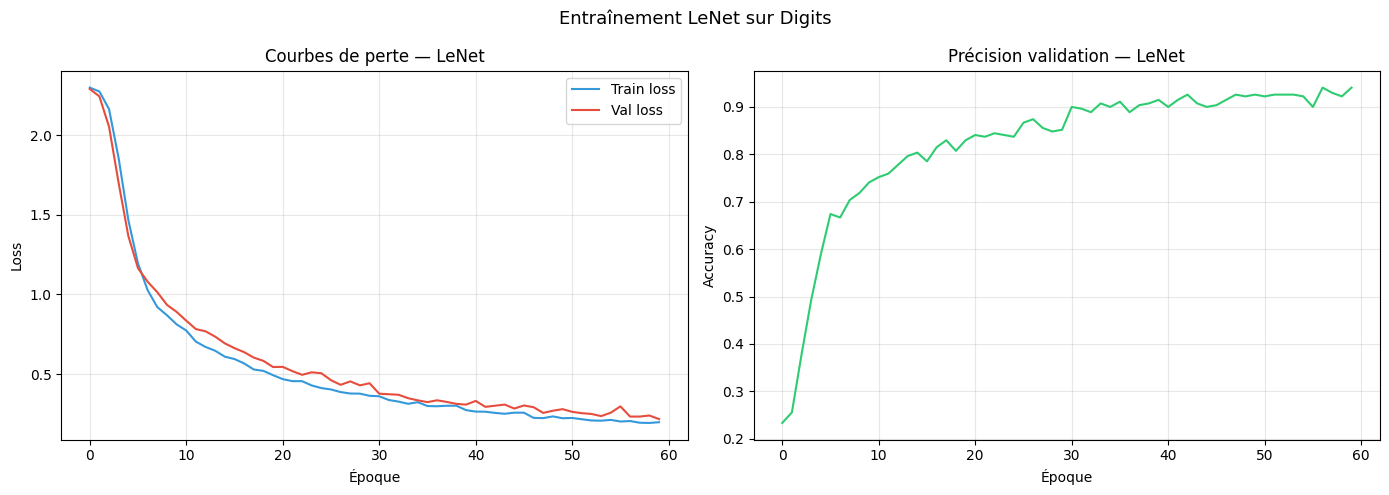

Figure sauvegardée : cnn_courbes_lenet.png


In [14]:
print("=" * 50)
print("ENTRAÎNEMENT LeNet")
print("=" * 50)

model_lenet = LeNet()
t0 = time.time()
historique_lenet, model_lenet = entrainer_cnn(model_lenet, train_loader, val_loader, epochs=60)
temps_lenet = time.time() - t0
print(f"Temps d'entraînement : {temps_lenet:.1f}s")

# Courbes d'apprentissage
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(historique_lenet['train_loss'], label='Train loss', color='#3498db')
axes[0].plot(historique_lenet['val_loss'], label='Val loss', color='#e74c3c')
axes[0].set_title("Courbes de perte — LeNet")
axes[0].set_xlabel("Époque"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(historique_lenet['val_acc'], color='#2ecc71')
axes[1].set_title("Précision validation — LeNet")
axes[1].set_xlabel("Époque"); axes[1].set_ylabel("Accuracy")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Entraînement LeNet sur Digits", fontsize=13)
plt.tight_layout()
plt.savefig("cnn_courbes_lenet.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : cnn_courbes_lenet.png")

## Cellule 14 — ÉTUDE EXPÉRIMENTALE : INFLUENCE DES CHOIX ARCHITECTURAUX

ÉTUDE EXPÉRIMENTALE — CHOIX ARCHITECTURAUX

→ Baseline (pad=1, avg-pool, 6/16 filtres)

Meilleure val_acc : 0.9037
  Paramètres :   3350 | val_acc : 0.9037 | temps : 3.3s

→ Sans padding

Meilleure val_acc : 0.8556
  Paramètres :   1814 | val_acc : 0.8556 | temps : 3.7s

→ Stride=2 (sous-échantillonnage agressif)

Meilleure val_acc : 0.6074
  Paramètres :   1814 | val_acc : 0.6074 | temps : 3.1s

→ Max-pooling au lieu de avg-pooling

Meilleure val_acc : 0.9593
  Paramètres :   3350 | val_acc : 0.9593 | temps : 3.3s

→ Plus de filtres (16/32)

Meilleure val_acc : 0.9370
  Paramètres :   9258 | val_acc : 0.9370 | temps : 4.1s

→ Avec convolution 1x1

Meilleure val_acc : 0.8815
  Paramètres :   3392 | val_acc : 0.8815 | temps : 4.9s

Configuration                                 |   Params |  Val Acc |  Temps
----------------------------------------------------------------------
Baseline (pad=1, avg-pool, 6/16 filtres)      |     3350 |   0.9037 |   3.3s
Sans padding                      

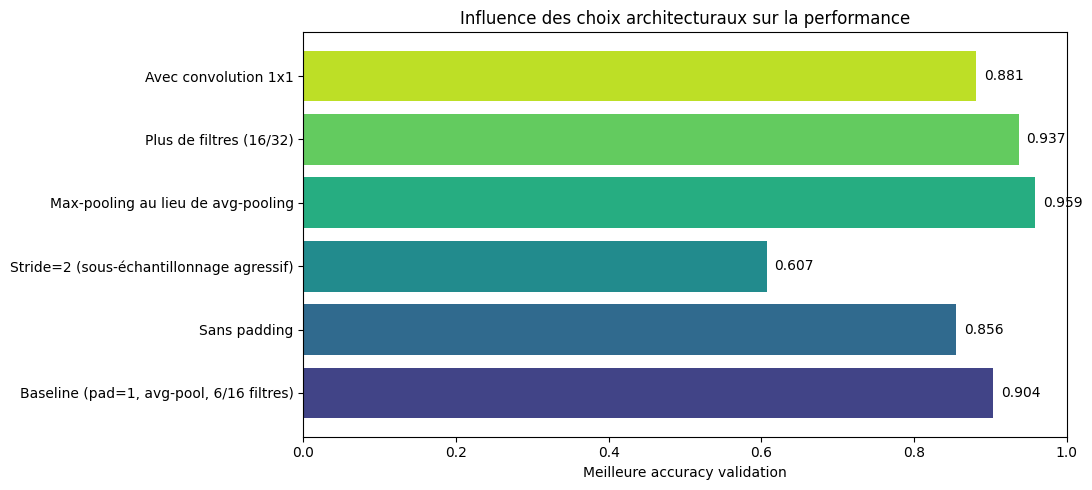

Figure sauvegardée : cnn_comparaison_architectures.png


In [31]:
class CNN_Variante(nn.Module):
    def __init__(self, padding=1, stride_conv=1, pool_type='avg',
                 n_filters1=6, n_filters2=16, use_1x1=False, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, n_filters1, kernel_size=3,
                                padding=padding, stride=stride_conv)

        layers_after_conv1 = []
        if use_1x1:
            layers_after_conv1.append(nn.Conv2d(n_filters1, n_filters1, kernel_size=1))
        self.conv1x1 = nn.Sequential(*layers_after_conv1) if use_1x1 else None

        self.pool1 = (nn.MaxPool2d(2, stride=2) if pool_type == 'max'
                      else nn.AvgPool2d(2, stride=2))

        self.conv2 = nn.Conv2d(n_filters1, n_filters2, kernel_size=3, padding=1)
        self.pool2 = (nn.MaxPool2d(2, stride=2) if pool_type == 'max'
                      else nn.AvgPool2d(2, stride=2))

        with torch.no_grad():
            dummy = torch.zeros(1, 1, 8, 8)
            d = torch.relu(self.conv1(dummy))
            if self.conv1x1 is not None:
                d = self.conv1x1(d)
            d = self.pool1(d)
            d = torch.relu(self.conv2(d))
            d = self.pool2(d)
            flat_size = d.view(1, -1).size(1)

        self.fc1 = nn.Linear(flat_size, 32)
        self.fc2 = nn.Linear(32, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        if self.conv1x1 is not None:
            x = self.conv1x1(x)
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

configs = {
    "Baseline (pad=1, avg-pool, 6/16 filtres)":
        dict(padding=1, stride_conv=1, pool_type='avg', n_filters1=6, n_filters2=16),
    "Sans padding":
        dict(padding=0, stride_conv=1, pool_type='avg', n_filters1=6, n_filters2=16),
    "Stride=2 (sous-échantillonnage agressif)":
        dict(padding=1, stride_conv=2, pool_type='avg', n_filters1=6, n_filters2=16),
    "Max-pooling au lieu de avg-pooling":
        dict(padding=1, stride_conv=1, pool_type='max', n_filters1=6, n_filters2=16),
    "Plus de filtres (16/32)":
        dict(padding=1, stride_conv=1, pool_type='avg', n_filters1=16, n_filters2=32),
    "Avec convolution 1x1":
        dict(padding=1, stride_conv=1, pool_type='avg', n_filters1=6, n_filters2=16, use_1x1=True),
}

print("=" * 50)
print("ÉTUDE EXPÉRIMENTALE — CHOIX ARCHITECTURAUX")
print("=" * 50)

resultats_experiences = {}
for nom, params in configs.items():
    print(f"\n→ {nom}")
    m = CNN_Variante(**params)
    n_params = sum(p.numel() for p in m.parameters())
    t0 = time.time()
    hist, m = entrainer_cnn(m, train_loader, val_loader, epochs=30, verbose=False)
    temps = time.time() - t0
    best_acc = max(hist['val_acc'])
    resultats_experiences[nom] = {
        'val_acc': best_acc, 'n_params': n_params, 'temps': temps, 'history': hist
    }
    print(f"  Paramètres : {n_params:6d} | val_acc : {best_acc:.4f} | temps : {temps:.1f}s")

print("\n" + "=" * 70)
print(f"{'Configuration':45s} | {'Params':>8s} | {'Val Acc':>8s} | {'Temps':>6s}")
print("-" * 70)
for nom, res in resultats_experiences.items():
    print(f"{nom:45s} | {res['n_params']:8d} | {res['val_acc']:8.4f} | {res['temps']:5.1f}s")

fig, ax = plt.subplots(figsize=(11, 5))
noms = list(resultats_experiences.keys())
accs = [resultats_experiences[n]['val_acc'] for n in noms]
colors_bar = plt.cm.viridis(np.linspace(0.2, 0.9, len(noms)))
bars = ax.barh(noms, accs, color=colors_bar)
ax.set_xlabel("Meilleure accuracy validation")
ax.set_title("Influence des choix architecturaux sur la performance")
ax.set_xlim(0, 1)
for bar, acc in zip(bars, accs):
    ax.text(acc + 0.01, bar.get_y() + bar.get_height()/2, f"{acc:.3f}", va='center')
plt.tight_layout()
plt.savefig("cnn_comparaison_architectures.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : cnn_comparaison_architectures.png")

## Cellule 15 — VISUALISATION DES CARTES DE CARACTÉRISTIQUES (FEATURE MAPS)

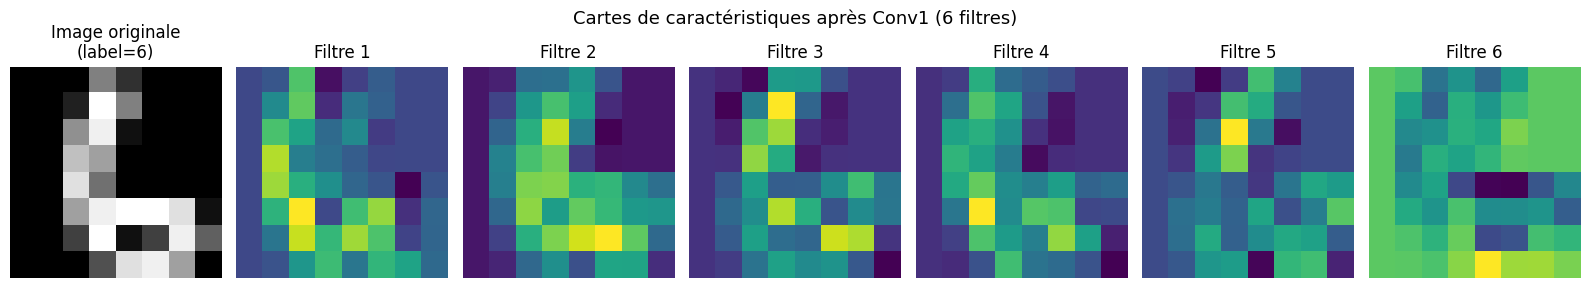

Figure sauvegardée : cnn_feature_maps.png

Chaque filtre réagit différemment aux motifs locaux de l'image (bords, courbes, zones pleines), illustrant la hiérarchie des représentations apprises par le CNN.


In [32]:
model_lenet.eval()
exemple_image = torch.FloatTensor(X_test[0]).unsqueeze(0).unsqueeze(0).to(device)

with torch.no_grad():
    feature_maps_conv1 = torch.sigmoid(model_lenet.conv1(exemple_image))

feature_maps_conv1 = feature_maps_conv1.squeeze(0).cpu()

fig, axes = plt.subplots(1, 7, figsize=(16, 3))
axes[0].imshow(X_test[0], cmap='gray')
axes[0].set_title(f"Image originale\n(label={y_test[0]})")
axes[0].axis('off')

for i in range(6):
    axes[i+1].imshow(feature_maps_conv1[i], cmap='viridis')
    axes[i+1].set_title(f"Filtre {i+1}")
    axes[i+1].axis('off')

plt.suptitle("Cartes de caractéristiques après Conv1 (6 filtres)", fontsize=13)
plt.tight_layout()
plt.savefig("cnn_feature_maps.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : cnn_feature_maps.png")
print("\nChaque filtre réagit différemment aux motifs locaux de l'image "
      "(bords, courbes, zones pleines), illustrant la hiérarchie des "
      "représentations apprises par le CNN.")

## Cellule 16 — COMPARAISON MLP SIMPLE vs CNN SUR LE MÊME DATASET

COMPARAISON MLP vs CNN — MÊME DATASET

Meilleure val_acc : 0.9778

Modèle     | Paramètres |  Val Acc |  Temps
---------------------------------------------
MLP        |       6570 |   0.9778 |   2.1s
CNN(LeNet) |       3350 |   0.9407 |  19.0s


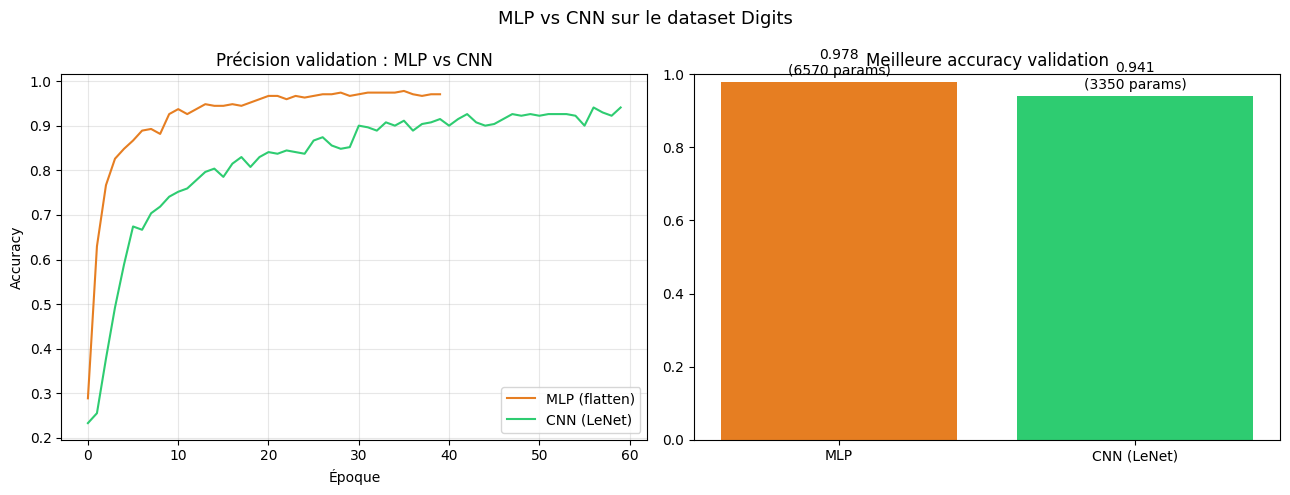

Figure sauvegardée : cnn_vs_mlp.png


In [33]:
class MLP_Images(nn.Module):
    def __init__(self, input_dim=64, hidden=64, num_classes=10):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden)
        self.fc2 = nn.Linear(hidden, 32)
        self.fc3 = nn.Linear(32, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

print("=" * 50)
print("COMPARAISON MLP vs CNN — MÊME DATASET")
print("=" * 50)

model_mlp_img = MLP_Images()
n_params_mlp = sum(p.numel() for p in model_mlp_img.parameters())
t0 = time.time()
hist_mlp, model_mlp_img = entrainer_cnn(model_mlp_img, train_loader, val_loader, epochs=40, verbose=False)
temps_mlp = time.time() - t0

n_params_cnn = sum(p.numel() for p in model_lenet.parameters())

print(f"\n{'Modèle':10s} | {'Paramètres':>10s} | {'Val Acc':>8s} | {'Temps':>6s}")
print("-" * 45)
print(f"{'MLP':10s} | {n_params_mlp:10d} | {max(hist_mlp['val_acc']):8.4f} | {temps_mlp:5.1f}s")
print(f"{'CNN(LeNet)':10s} | {n_params_cnn:10d} | {max(historique_lenet['val_acc']):8.4f} | {temps_lenet:5.1f}s")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(hist_mlp['val_acc'], label='MLP (flatten)', color='#e67e22')
axes[0].plot(historique_lenet['val_acc'], label='CNN (LeNet)', color='#2ecc71')
axes[0].set_title("Précision validation : MLP vs CNN")
axes[0].set_xlabel("Époque"); axes[0].set_ylabel("Accuracy")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

modeles = ['MLP', 'CNN (LeNet)']
params_compare = [n_params_mlp, n_params_cnn]
accs_compare = [max(hist_mlp['val_acc']), max(historique_lenet['val_acc'])]
axes[1].bar(modeles, accs_compare, color=['#e67e22', '#2ecc71'])
axes[1].set_title("Meilleure accuracy validation")
axes[1].set_ylim(0, 1)
for i, (acc, p) in enumerate(zip(accs_compare, params_compare)):
    axes[1].text(i, acc + 0.02, f"{acc:.3f}\n({p} params)", ha='center')

plt.suptitle("MLP vs CNN sur le dataset Digits", fontsize=13)
plt.tight_layout()
plt.savefig("cnn_vs_mlp.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : cnn_vs_mlp.png")

## Cellule 17 — ÉVALUATION FINALE SUR LE TEST SET (LeNet)

ÉVALUATION FINALE SUR LE TEST SET — LeNet

Accuracy  : 0.1037
Precision (macro) : 0.0104
Recall (macro)    : 0.1000
F1-Score (macro)  : 0.0188

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        27
           1       0.00      0.00      0.00        28
           2       0.00      0.00      0.00        26
           3       0.10      1.00      0.19        28
           4       0.00      0.00      0.00        27
           5       0.00      0.00      0.00        27
           6       0.00      0.00      0.00        27
           7       0.00      0.00      0.00        27
           8       0.00      0.00      0.00        26
           9       0.00      0.00      0.00        27

    accuracy                           0.10       270
   macro avg       0.01      0.10      0.02       270
weighted avg       0.01      0.10      0.02       270



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

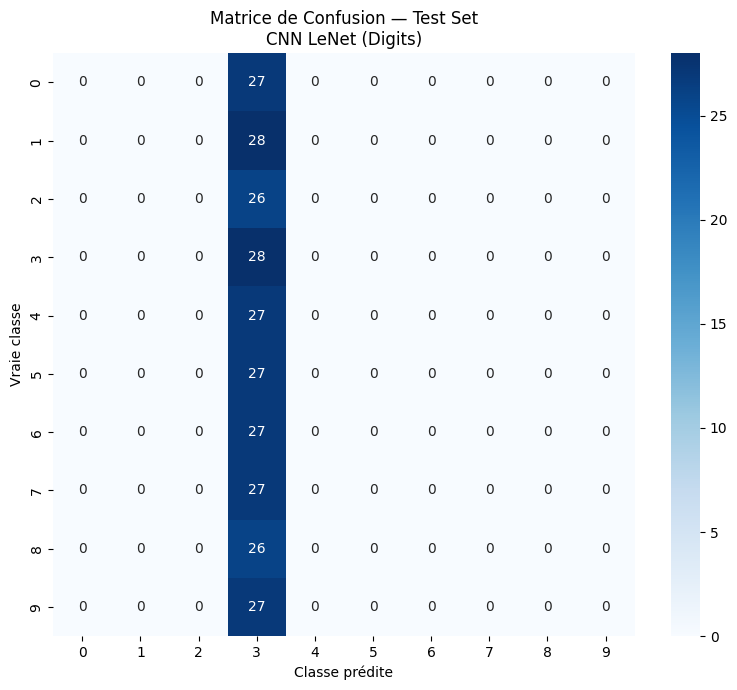

Figure sauvegardée : cnn_matrice_confusion.png


In [34]:
def evaluer_modele(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())
    return np.array(all_labels), np.array(all_preds)

y_true, y_pred = evaluer_modele(model_lenet, test_loader, device)

print("=" * 50)
print("ÉVALUATION FINALE SUR LE TEST SET — LeNet")
print("=" * 50)
print(f"\nAccuracy  : {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision (macro) : {precision_score(y_true, y_pred, average='macro'):.4f}")
print(f"Recall (macro)    : {recall_score(y_true, y_pred, average='macro'):.4f}")
print(f"F1-Score (macro)  : {f1_score(y_true, y_pred, average='macro'):.4f}")
print()
print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title("Matrice de Confusion — Test Set\nCNN LeNet (Digits)", fontsize=12)
ax.set_ylabel("Vraie classe")
ax.set_xlabel("Classe prédite")
plt.tight_layout()
plt.savefig("cnn_matrice_confusion.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : cnn_matrice_confusion.png")

## Cellule 18 — SAUVEGARDE DU MODÈLE

In [19]:
torch.save(model_lenet.state_dict(), "lenet_digits.pth")
print("Modèle sauvegardé : lenet_digits.pth")

Modèle sauvegardé : lenet_digits.pth


## Cellule 19 — TABLEAU RÉCAPITULATIF FINAL

In [20]:
print("\n" + "=" * 55)
print("RÉCAPITULATIF — PARTIE II : CNN SUR DATASET DIGITS")
print("=" * 55)

print("\n1. VÉRIFICATIONS MANUELLES")
print("   corr2d manuel ≡ nn.Conv2d PyTorch  ✓")
print("   pool2d manuel ≡ nn.MaxPool2d/AvgPool2d PyTorch  ✓")

print("\n2. ARCHITECTURE LeNet")
print(f"   Paramètres totaux : {n_params_cnn}")
print(f"   Dimensions : (1,8,8) → Conv1 → (6,8,8) → Pool → (6,4,4)")
print(f"                → Conv2 → (16,4,4) → Pool → (16,2,2) → Flatten(64)")

print("\n3. ÉTUDE EXPÉRIMENTALE (6 configurations testées)")
for nom, res in resultats_experiences.items():
    print(f"   {nom:45s} → val_acc = {res['val_acc']:.4f}")

print("\n4. COMPARAISON MLP vs CNN")
print(f"   MLP        : {n_params_mlp} params → val_acc = {max(hist_mlp['val_acc']):.4f}")
print(f"   CNN(LeNet) : {n_params_cnn} params → val_acc = {max(historique_lenet['val_acc']):.4f}")

print("\n5. RÉSULTATS TEST SET (LeNet)")
print(f"   Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
print(f"   F1-macro  : {f1_score(y_true, y_pred, average='macro'):.4f}")

print("\n6. FICHIERS PRODUITS")
for f in ["cnn_exemples_dataset.png", "cnn_detection_contours.png",
          "cnn_courbes_lenet.png", "cnn_comparaison_architectures.png",
          "cnn_feature_maps.png", "cnn_vs_mlp.png", "cnn_matrice_confusion.png",
          "lenet_digits.pth"]:
    print(f"   - {f}")

print("\nPARTIE II TERMINÉE ✓")


RÉCAPITULATIF — PARTIE II : CNN SUR DATASET DIGITS

1. VÉRIFICATIONS MANUELLES
   corr2d manuel ≡ nn.Conv2d PyTorch  ✓
   pool2d manuel ≡ nn.MaxPool2d/AvgPool2d PyTorch  ✓

2. ARCHITECTURE LeNet
   Paramètres totaux : 3350
   Dimensions : (1,8,8) → Conv1 → (6,8,8) → Pool → (6,4,4)
                → Conv2 → (16,4,4) → Pool → (16,2,2) → Flatten(64)

3. ÉTUDE EXPÉRIMENTALE (6 configurations testées)
   Baseline (pad=1, avg-pool, 6/16 filtres)      → val_acc = 0.8630
   Sans padding                                  → val_acc = 0.8259
   Stride=2 (sous-échantillonnage agressif)      → val_acc = 0.6444
   Max-pooling au lieu de avg-pooling            → val_acc = 0.9519
   Plus de filtres (16/32)                       → val_acc = 0.9222
   Avec convolution 1x1                          → val_acc = 0.8926

4. COMPARAISON MLP vs CNN
   MLP        : 6570 params → val_acc = 0.9667
   CNN(LeNet) : 3350 params → val_acc = 0.9407

5. RÉSULTATS TEST SET (LeNet)
   Accuracy  : 0.9222
   F1-macro  : 0.